In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import svm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import statsmodels.api as sm
df = pd.read_csv("C:/Users/mickt/Downloads/Speed+Dating+Data.csv", encoding='windows-1252')
df

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8373,552,22.0,1,44,2,21,22,14,10.0,5,...,8.0,5.0,7.0,6.0,7.0,9.0,5.0,9.0,5.0,6.0
8374,552,22.0,1,44,2,21,22,13,10.0,4,...,8.0,5.0,7.0,6.0,7.0,9.0,5.0,9.0,5.0,6.0
8375,552,22.0,1,44,2,21,22,19,10.0,10,...,8.0,5.0,7.0,6.0,7.0,9.0,5.0,9.0,5.0,6.0
8376,552,22.0,1,44,2,21,22,3,10.0,16,...,8.0,5.0,7.0,6.0,7.0,9.0,5.0,9.0,5.0,6.0


In [23]:
df.describe()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
count,8378.000000,8377.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,6532.000000,8378.000000,...,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000
mean,283.675937,8.960248,0.500597,17.327166,1.828837,11.350919,16.872046,9.042731,9.295775,8.927668,...,7.240312,8.093357,8.388777,7.658782,7.391545,6.810020,7.615079,7.932540,7.155258,7.048611
std,158.583367,5.491329,0.500029,10.940735,0.376673,5.995903,4.358458,5.514939,5.650199,5.477009,...,1.576596,1.610309,1.459094,1.744670,1.961417,1.507341,1.504551,1.340868,1.672787,1.717988
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,4.000000,1.000000,1.000000
25%,154.000000,4.000000,0.000000,8.000000,2.000000,7.000000,14.000000,4.000000,4.000000,4.000000,...,7.000000,7.000000,8.000000,7.000000,6.000000,6.000000,7.000000,7.000000,6.000000,6.000000
50%,281.000000,8.000000,1.000000,16.000000,2.000000,11.000000,18.000000,8.000000,9.000000,8.000000,...,7.000000,8.000000,8.000000,8.000000,8.000000,7.000000,8.000000,8.000000,7.000000,7.000000
75%,407.000000,13.000000,1.000000,26.000000,2.000000,15.000000,20.000000,13.000000,14.000000,13.000000,...,8.000000,9.000000,9.000000,9.000000,9.000000,8.000000,9.000000,9.000000,8.000000,8.000000
max,552.000000,22.000000,1.000000,44.000000,2.000000,21.000000,22.000000,22.000000,22.000000,22.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [67]:
df['match'].mean()
df['dec'].mean()
df.groupby('gender')['dec'].mean()

gender
0    0.365440
1    0.474249
Name: dec, dtype: float64

In [ ]:
df.shape

(8378, 195)

In [115]:
df.dropna()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3


In [116]:
df.shape

(8378, 195)

In [124]:
df.attr1_1.max()

100.0

In [2]:
cols = ['attr1_1','sinc1_1','intel1_1',
        'fun1_1','amb1_1','shar1_1']

mask = df['wave'].isin([6,7,8,9])

df.loc[mask, cols] = (
    df.loc[mask, cols]
      .div(df.loc[mask, cols].sum(axis=1), axis=0) * 100
)

In [129]:
df.attr1_1.max()

30.901986620937787

In [56]:
non_numeric = df.select_dtypes(exclude=["number", "bool"]).columns
print(non_numeric.tolist())

['field', 'undergra', 'mn_sat', 'tuition', 'from', 'zipcode', 'income', 'career']


In [57]:
numeric = df.select_dtypes(include=["number", "bool"]).columns
print(numeric.tolist())

['iid', 'id', 'gender', 'idg', 'condtn', 'wave', 'round', 'position', 'positin1', 'order', 'partner', 'pid', 'match', 'int_corr', 'samerace', 'age_o', 'race_o', 'pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun', 'pf_o_amb', 'pf_o_sha', 'dec_o', 'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o', 'like_o', 'prob_o', 'met_o', 'age', 'field_cd', 'race', 'imprace', 'imprelig', 'goal', 'date', 'go_out', 'career_c', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'exphappy', 'expnum', 'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1', 'attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1', 'attr2_1', 'sinc2_1', 'intel2_1', 'fun2_1', 'amb2_1', 'shar2_1', 'attr3_1', 'sinc3_1', 'fun3_1', 'intel3_1', 'amb3_1', 'attr5_1', 'sinc5_1', 'intel5_1', 'fun5_1', 'amb5_1', 'dec', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob', 'met', 'match_

## What are the least desirable attributes in a male partner? Does this differ for female partners?

In [36]:
preferred_attrs_female = df.loc[df['gender'] == 0, ['attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o']]
preferred_attrs_male = df.loc[df['gender'] == 1, ['attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o']]
preferred_attrs_match = df.loc[df['match'] == 1, ['attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o']]
print(preferred_attrs_match.value_counts().sort_values(ascending=True).head(10)) 
print(preferred_attrs_match.value_counts().sort_values(ascending=False).head(10))

attr_o  sinc_o  intel_o  fun_o  amb_o
4.0     10.0    9.0      5.0    6.0      1
8.0     8.0     8.0      6.0    4.0      1
                                9.0      1
        10.0    8.0      6.0    9.0      1
                         8.0    7.0      1
                         9.0    9.0      1
                9.0      7.0    5.0      1
                                8.0      1
                         8.0    7.0      1
10.0    7.0     8.0      7.0    9.0      1
Name: count, dtype: int64
attr_o  sinc_o  intel_o  fun_o  amb_o
10.0    10.0    10.0     10.0   10.0     38
8.0     8.0     8.0      8.0    8.0      31
7.0     7.0     7.0      7.0    7.0      18
9.0     9.0     9.0      9.0    9.0      16
8.0     8.0     8.0      8.0    7.0      13
                7.0      7.0    7.0      10
6.0     8.0     8.0      7.0    7.0       8
9.0     8.0     8.0      8.0    8.0       8
6.0     6.0     6.0      6.0    6.0       7
8.0     7.0     7.0      7.0    7.0       7
Name: count, dtype: int64


In [38]:
print(preferred_attrs_female.value_counts().sort_values(ascending=True).head(10)) 
print(preferred_attrs_female.value_counts().sort_values(ascending=False).head(10))

attr_o  sinc_o  intel_o  fun_o  amb_o
10.0    9.0     8.0      7.0    8.0      1
        7.0     9.0      8.0    6.0      1
9.0     10.0    10.0     10.0   9.0      1
9.5     9.0     9.5      7.0    7.0      1
9.9     8.0     8.0      8.0    8.0      1
10.0    5.0     5.0      5.0    7.0      1
                6.0      10.0   10.0     1
                10.0     5.0    5.0      1
        6.0     8.0      10.0   6.0      1
2.0     4.0     4.0      2.0    5.0      1
Name: count, dtype: int64
attr_o  sinc_o  intel_o  fun_o  amb_o
10.0    10.0    10.0     10.0   10.0     66
8.0     8.0     8.0      8.0    8.0      56
5.0     5.0     5.0      5.0    5.0      52
7.0     7.0     7.0      7.0    7.0      47
6.0     6.0     6.0      6.0    6.0      30
8.0     8.0     8.0      8.0    7.0      22
9.0     9.0     9.0      9.0    9.0      21
6.0     7.0     7.0      7.0    7.0      15
8.0     8.0     7.0      7.0    7.0      15
6.0     8.0     8.0      7.0    7.0      14
Name: count, dtype: int64


In [39]:
print(preferred_attrs_male.value_counts().sort_values(ascending=True).head(10)) 
print(preferred_attrs_male.value_counts().sort_values(ascending=False).head(10))

attr_o  sinc_o  intel_o  fun_o  amb_o
1.0     6.0     8.0      1.0    2.0      1
10.0    9.0     9.0      6.0    6.0      1
4.0     0.0     8.0      7.0    7.0      1
        1.0     4.0      1.0    10.0     1
                5.0      4.0    4.0      1
10.0    9.0     9.0      8.0    9.0      1
4.0     2.0     2.0      9.0    9.0      1
10.0    9.0     9.0      9.0    9.0      1
                         10.0   6.0      1
4.0     2.0     4.0      2.0    1.0      1
Name: count, dtype: int64
attr_o  sinc_o  intel_o  fun_o  amb_o
7.0     7.0     7.0      7.0    7.0      57
8.0     8.0     8.0      8.0    8.0      52
10.0    10.0    10.0     10.0   10.0     32
6.0     6.0     6.0      6.0    6.0      27
5.0     5.0     5.0      5.0    5.0      27
9.0     9.0     9.0      9.0    9.0      18
7.0     8.0     8.0      8.0    8.0      17
6.0     7.0     7.0      7.0    7.0      16
5.0     7.0     7.0      7.0    7.0      15
7.0     8.0     8.0      7.0    7.0      15
Name: count, dtype: int64


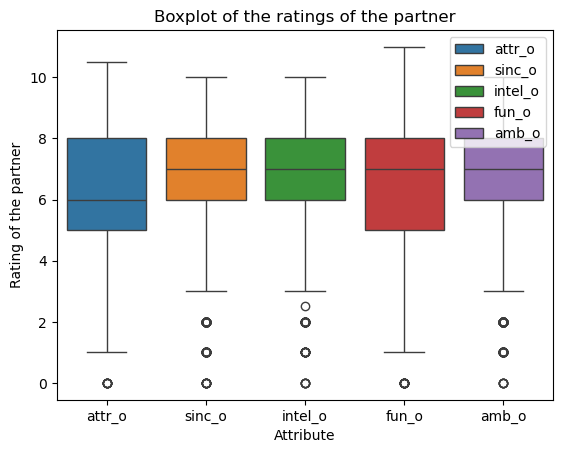

In [40]:
sns.boxplot(df[['attr_o', 'sinc_o',	'intel_o',	'fun_o',	'amb_o']], legend= True)
plt.xlabel("Attribute")
plt.ylabel("Rating of the partner")
plt.title("Boxplot of the ratings of the partner")
plt.show()

In [51]:
df.groupby('gender')[['attr1_1','sinc1_1','intel1_1',
                      'fun1_1','amb1_1','shar1_1']].mean()

,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1
gender,,,,,,
0,0.201863,0.266098,0.262976,0.253629,0.297284,0.272618
1,0.303621,0.240141,0.243225,0.253069,0.210328,0.236266


In [41]:
male_prefs = df.loc[df['gender'] == 1,
                    ['attr1_1', 'sinc1_1', 'intel1_1',
                     'fun1_1', 'amb1_1', 'shar1_1']]

male_prefs.mean()

attr1_1     26.921622
sinc1_1     16.498380
intel1_1    19.537304
fun1_1      17.763824
amb1_1       8.552765
shar1_1     10.996508
dtype: float64

In [42]:
male_means = male_prefs.mean()
male_means.sort_values(ascending=True)

amb1_1       8.552765
shar1_1     10.996508
sinc1_1     16.498380
fun1_1      17.763824
intel1_1    19.537304
attr1_1     26.921622
dtype: float64

In [43]:
female_prefs = df.loc[df['gender'] == 0,
                    ['attr1_1', 'sinc1_1', 'intel1_1',
                     'fun1_1', 'amb1_1', 'shar1_1']]

female_prefs.mean()

attr1_1     18.055171
sinc1_1     18.304963
intel1_1    21.002457
fun1_1      17.147249
amb1_1      12.827171
shar1_1     12.704155
dtype: float64

In [44]:
female_means = female_prefs.mean()
female_means.sort_values(ascending=True)

shar1_1     12.704155
amb1_1      12.827171
fun1_1      17.147249
attr1_1     18.055171
sinc1_1     18.304963
intel1_1    21.002457
dtype: float64

In [45]:
df['pf_o_att'].value_counts()

pf_o_att
20.00    1670
15.00     868
25.00     818
10.00     807
30.00     679
         ... 
80.00       9
90.00       9
12.77       5
18.75       5
20.83       5
Name: count, Length: 94, dtype: int64

In [89]:
attributes = ['attr_o','sinc_o','intel_o',
              'fun_o','amb_o','shar_o']

df[attributes].mean().sort_values(ascending=False)

intel_o    7.369301
sinc_o     7.175256
amb_o      6.778409
fun_o      6.400599
attr_o     6.190411
shar_o     5.474870
dtype: float64

In [97]:
df.groupby('gender')[attributes].mean().T

gender,0,1
attr_o,6.461401,5.919422
sinc_o,7.251053,7.099778
intel_o,7.291202,7.447362
fun_o,6.520164,6.280555
amb_o,6.604591,6.952773
shar_o,5.541148,5.407012


### Shared interest rated the lowest among the 6 attributes rated 

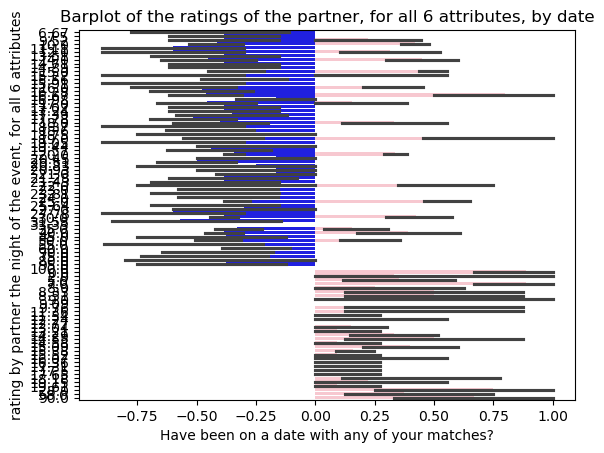

In [71]:

df_f = df[df.gender == 1].loc[::-1]
df_m = df[df.gender == 0].loc[::-1]

ax = sns.barplot(y=df_m['pf_o_att'], x=df_m["date_3"] * -1, orient="h", color="blue")
ax = sns.barplot(y=df_f['pf_o_att'], x=df_f["date_3"], orient="h", color="pink")
plt.xlabel("Have been on a date with any of your matches?")
plt.ylabel("rating by partner the night of the event, for all 6 attributes")
plt.title("Barplot of the ratings of the partner, for all 6 attributes, by date")
plt.show()

## How important do people think attractiveness is in potential mate selection vs. its real impact?

In [47]:
preferred_attrs_male = df.loc[df['gender'] == 1, ['attr_o','attr1_1','sinc_o', 'intel_o', 'fun_o', 'amb_o']]
preferred_attrs_female = df.loc[df['gender'] == 0, ['attr_o', 'attr1_1', 'sinc_o', 'intel_o', 'fun_o', 'amb_o']]
preferred_attrs_match = df.loc[df['match'] == 1, ['attr_o', 'attr1_1', 'sinc_o', 'intel_o', 'fun_o', 'amb_o']]

In [48]:
print(preferred_attrs_match['attr_o'].value_counts().sort_values(ascending=True).head(10))
print(preferred_attrs_match['attr_o'].value_counts().sort_values(ascending=False).head(10))

attr_o
10.5      1
9.5       1
6.5       3
2.0       4
1.0       5
3.0       9
4.0      37
5.0     106
10.0    114
9.0     177
Name: count, dtype: int64
attr_o
8.0     365
7.0     339
6.0     216
9.0     177
10.0    114
5.0     106
4.0      37
3.0       9
1.0       5
2.0       4
Name: count, dtype: int64


In [50]:
print(preferred_attrs_male['attr1_1'].value_counts().sort_values(ascending=False).head(10))
print(preferred_attrs_female['attr1_1'].value_counts().sort_values(ascending=False).head(10))

attr1_1
20.000000    841
25.000000    560
30.000000    553
40.000000    289
50.000000    199
35.000000    157
15.000000    124
10.000000    121
60.000000     57
17.778222     52
Name: count, dtype: int64
attr1_1
20.00    810
15.00    744
10.00    686
25.00    261
30.00    126
16.00    121
50.00    102
15.38     76
40.00     71
5.00      60
Name: count, dtype: int64


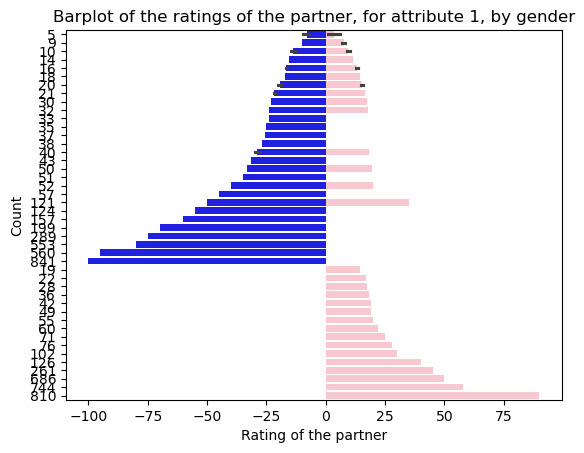

In [66]:
sns.barplot(x=preferred_attrs_male['attr1_1'].value_counts().sort_index(ascending=True).index * -1, y=preferred_attrs_male['attr1_1'].value_counts().sort_values(ascending=True).values, color="blue",orient="h")
sns.barplot(x=preferred_attrs_female['attr1_1'].value_counts().sort_index(ascending=True).index, y=preferred_attrs_female['attr1_1'].value_counts().sort_values(ascending=True).values, color="pink", orient="h")
plt.xlabel("Rating of the partner")
plt.ylabel("Count")
plt.title("Barplot of the ratings of the partner, for attribute 1, by gender")
plt.show()

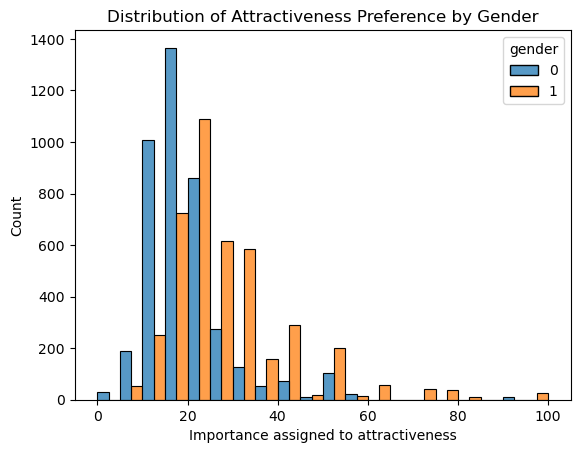

In [69]:
sns.histplot(
    data=df,
    x='attr1_1',
    hue='gender',
    bins=20,
    multiple='dodge'
)

plt.title("Distribution of Attractiveness Preference by Gender")
plt.xlabel("Importance assigned to attractiveness")
plt.show()

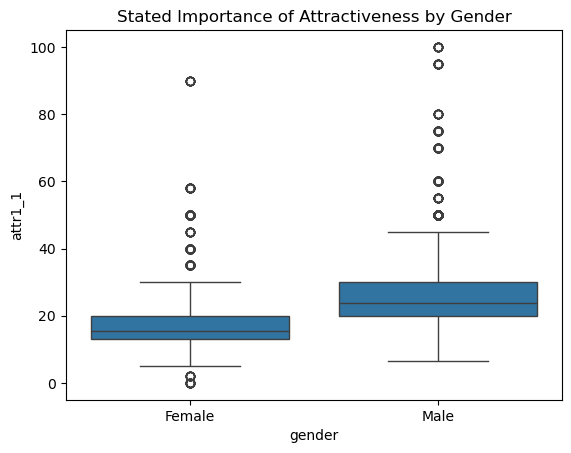

In [72]:
sns.boxplot(data=df, x='gender', y='attr1_1')
plt.xticks([0,1], ['Female','Male'])
plt.title("Stated Importance of Attractiveness by Gender")
plt.show()

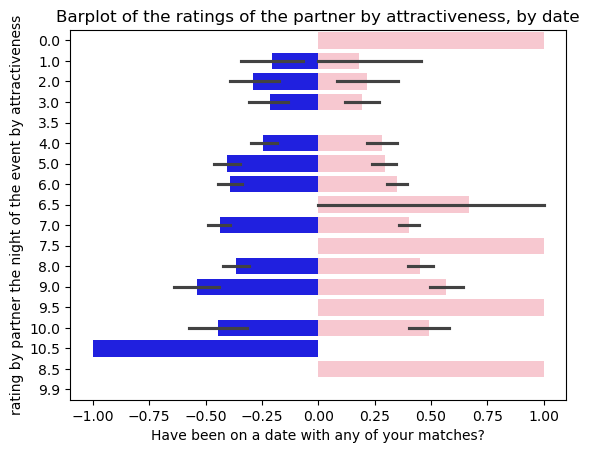

In [136]:

df_f = df[df.gender == 0].loc[::-1]
df_m = df[df.gender == 1].loc[::-1]

ax = sns.barplot(y=df_m["attr_o"], x=df_m["date_3"] * -1, orient="h", color="blue")
ax = sns.barplot(y=df_f["attr_o"], x=df_f["date_3"], orient="h", color="pink")
plt.xlabel("Have been on a date with any of your matches?")
plt.ylabel("rating by partner the night of the event by attractiveness")
plt.title("Barplot of the ratings of the partner by attractiveness, by date")
plt.show()


## Are shared interests more important than a shared racial background?

### Rate of the importance of interests.

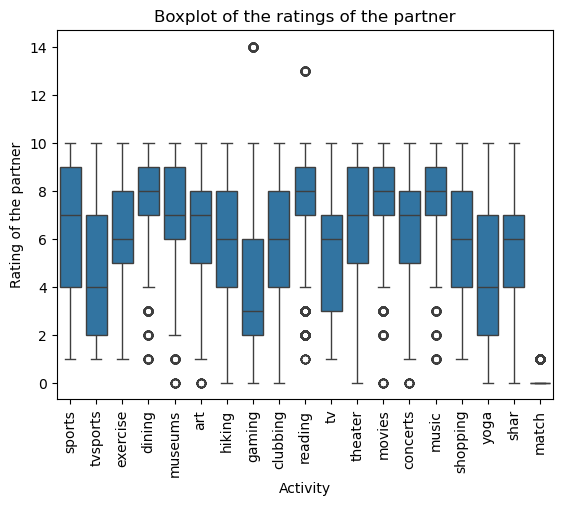

In [143]:
columns2 = ['sports',	'tvsports',	'exercise',	'dining',	'museums',	'art',	'hiking',	'gaming',	'clubbing',	'reading',	'tv',	'theater','movies',	'concerts',	'music',	'shopping',	'yoga', 'shar','match']
sns.boxplot(data=df[columns2].melt(var_name='Activity', value_name='Rating'), x='Activity', y='Rating', legend= True)
plt.xlabel("Activity")
plt.ylabel("Rating of the partner")
plt.title("Boxplot of the ratings of the partner")
plt.xticks(rotation=90)
plt.show()

In [144]:
df_match = df[df.match == 0].loc[::-1]
df_no_match = df[df.match == 1].loc[::-1]

In [145]:
df_match_male = df_match[df_match.gender == 1] 
df_match_female = df_match[df_match.gender == 0]
df_no_match_male = df_no_match[df_no_match.gender == 1] 
df_no_match_female = df_no_match[df_no_match.gender == 0]

In [146]:
df_match_male_final = df_match_male[columns2].melt(var_name='Activity', value_name='Rating')
df_match_female_final = df_match_female[columns2].melt(var_name='Activity', value_name='Rating')
df_no_match_male_final = df_no_match_male[columns2].melt(var_name='Activity', value_name='Rating')
df_no_match_female_final = df_no_match_female[columns2].melt(var_name='Activity', value_name='Rating')

In [147]:
df_match_male_final

,Activity,Rating
0,sports,8.0
1,sports,8.0
2,sports,8.0
3,sports,8.0
4,sports,8.0
...,...,...
66571,match,0.0
66572,match,0.0
66573,match,0.0
66574,match,0.0


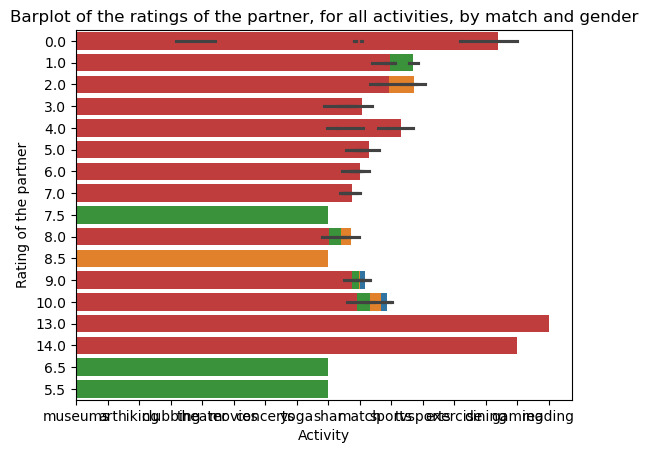

In [148]:
sns.barplot(data=df_match_male_final, x='Activity', y='Rating', orient="h")
sns.barplot(data=df_no_match_male_final, x='Activity', y='Rating', orient="h")
sns.barplot(data=df_match_female_final, x='Activity', y='Rating', orient="h")
sns.barplot(data=df_no_match_female_final, x='Activity', y='Rating', orient="h")
plt.xlabel("Activity")
plt.ylabel("Rating of the partner")
plt.title("Barplot of the ratings of the partner, for all activities, by match and gender")
plt.show()

In [149]:
df_match.match

8377    0
8376    0
8375    0
8374    0
8373    0
       ..
7       0
6       0
5       0
1       0
0       0
Name: match, Length: 6998, dtype: int64

In [150]:
df_match_ =df_match[columns3].melt(var_name='Activity', value_name='Rating')
df_no_match_ = df_no_match[columns3].melt(var_name='Activity', value_name='Rating')

<Axes: xlabel='Activity', ylabel='Rating'>

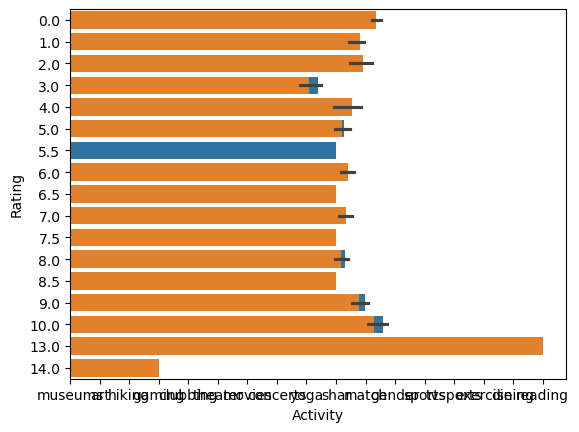

In [151]:
sns.barplot(data= df_match_, x='Activity', y='Rating', orient="h")
sns.barplot(data= df_no_match_, x='Activity', y='Rating', orient="h")

In [152]:
df.groupby(['gender','match'])[columns2].mean()

sports  tvsports  exercise    dining   museums       art  \
gender match                                                               
0      0      5.806676  4.192163  6.469666  8.127431  7.387228  7.164586   
       1      5.847059  4.011765  6.355882  8.247059  7.636765  7.498529   
1      0      6.985956  4.965033  6.004586  7.392089  6.562339  6.207223   
       1      7.254015  5.078832  6.239416  7.591241  6.477372  6.256934   

                hiking    gaming  clubbing   reading        tv   theater  \
gender match                                                               
0      0      5.910015  3.272279  5.825835  7.890566  5.731495  7.454282   
       1      6.104412  3.454412  6.275000  7.991176  5.779412  7.622059   
1      0      5.511608  4.451132  5.544855  7.433362  4.914589  6.106334   
       1      5.651095  4.464234  5.843796  7.550365  4.667153  5.937226   

                movies  concerts     music  shopping      yoga      shar  \
gender match                                                               
0      0      8.201451  7.055152  7.973585  6.497823  4.943106  5.104390   
       1      8.180882  7.350000  8.070588  6.505882  5.226471  6.854167   
1      0      7.675838  6.547148  7.693608  4.778733  3.655202  5.309260   
       1      7.484672  6.566423  7.818978  4.747445  3.905109  6.654874   

              match  
gender match         
0      0        0.0  
       1        1.0  
1      0        0.0  
       1        1.0

In [153]:
df_melted = df.melt(
    id_vars=['match','gender'],
    value_vars=columns2,
    var_name='Activity',
    value_name='Rating'
)

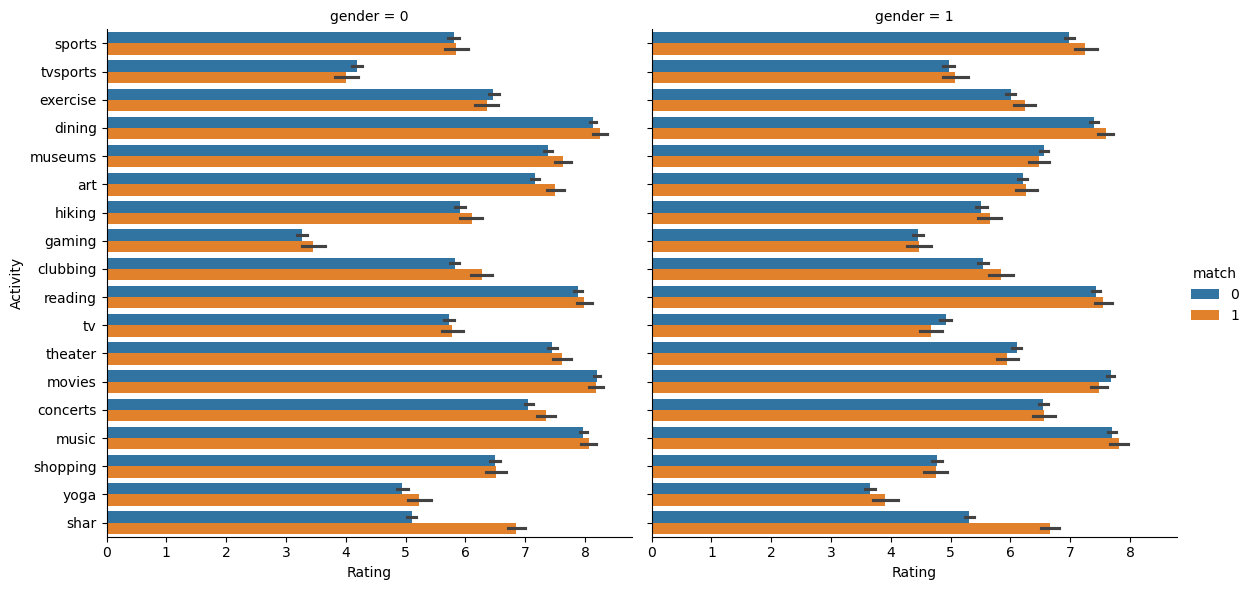

In [154]:
sns.catplot(
    data=df_melted,
    x='Rating',
    y='Activity',
    hue='match',
    col='gender',
    kind='bar',
    height=6,
    aspect=1
)

<Axes: >

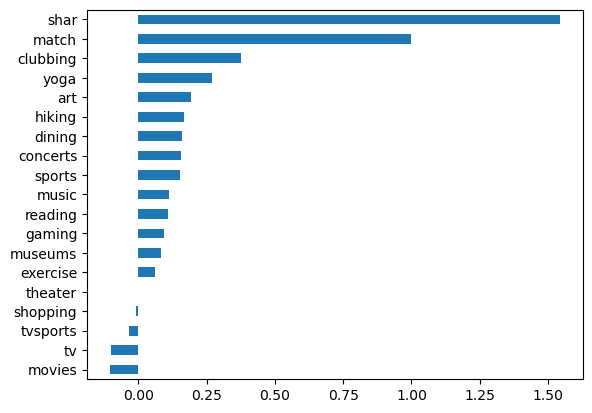

In [ ]:
diff = (
    df[df.match==1][columns2].mean()
    - df[df.match==0][columns2].mean()
)
diff.sort_values().plot(kind='barh')

### After visualization, we can observe that clubbing, yoga, art, hiking, dining, concert, sport, music, reading, gaming, museum, and exeercise showed an overall increased rating.

### Does shared race matter more than shared interest ?

In [156]:
df[['samerace','shar','match']].corr().style.background_gradient(cmap='coolwarm')

,samerace,shar,match
samerace,1.000000,0.061505,0.013028
shar,0.061505,1.000000,0.270679
match,0.013028,0.270679,1.000000


<Axes: xlabel='samerace', ylabel='match'>

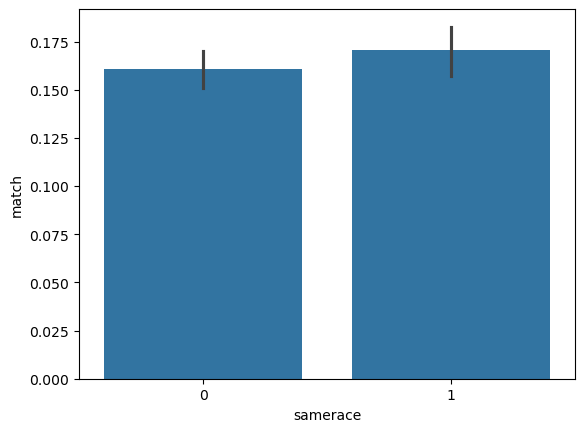

In [157]:
sns.barplot(x='samerace', y='match', data=df)

### There was .27 of correlation between shared interests, but the samerace showed only .06, which concludes that race was not more important within the studied population.

## Can people accurately predict their own perceived value in the dating market?

<Axes: >

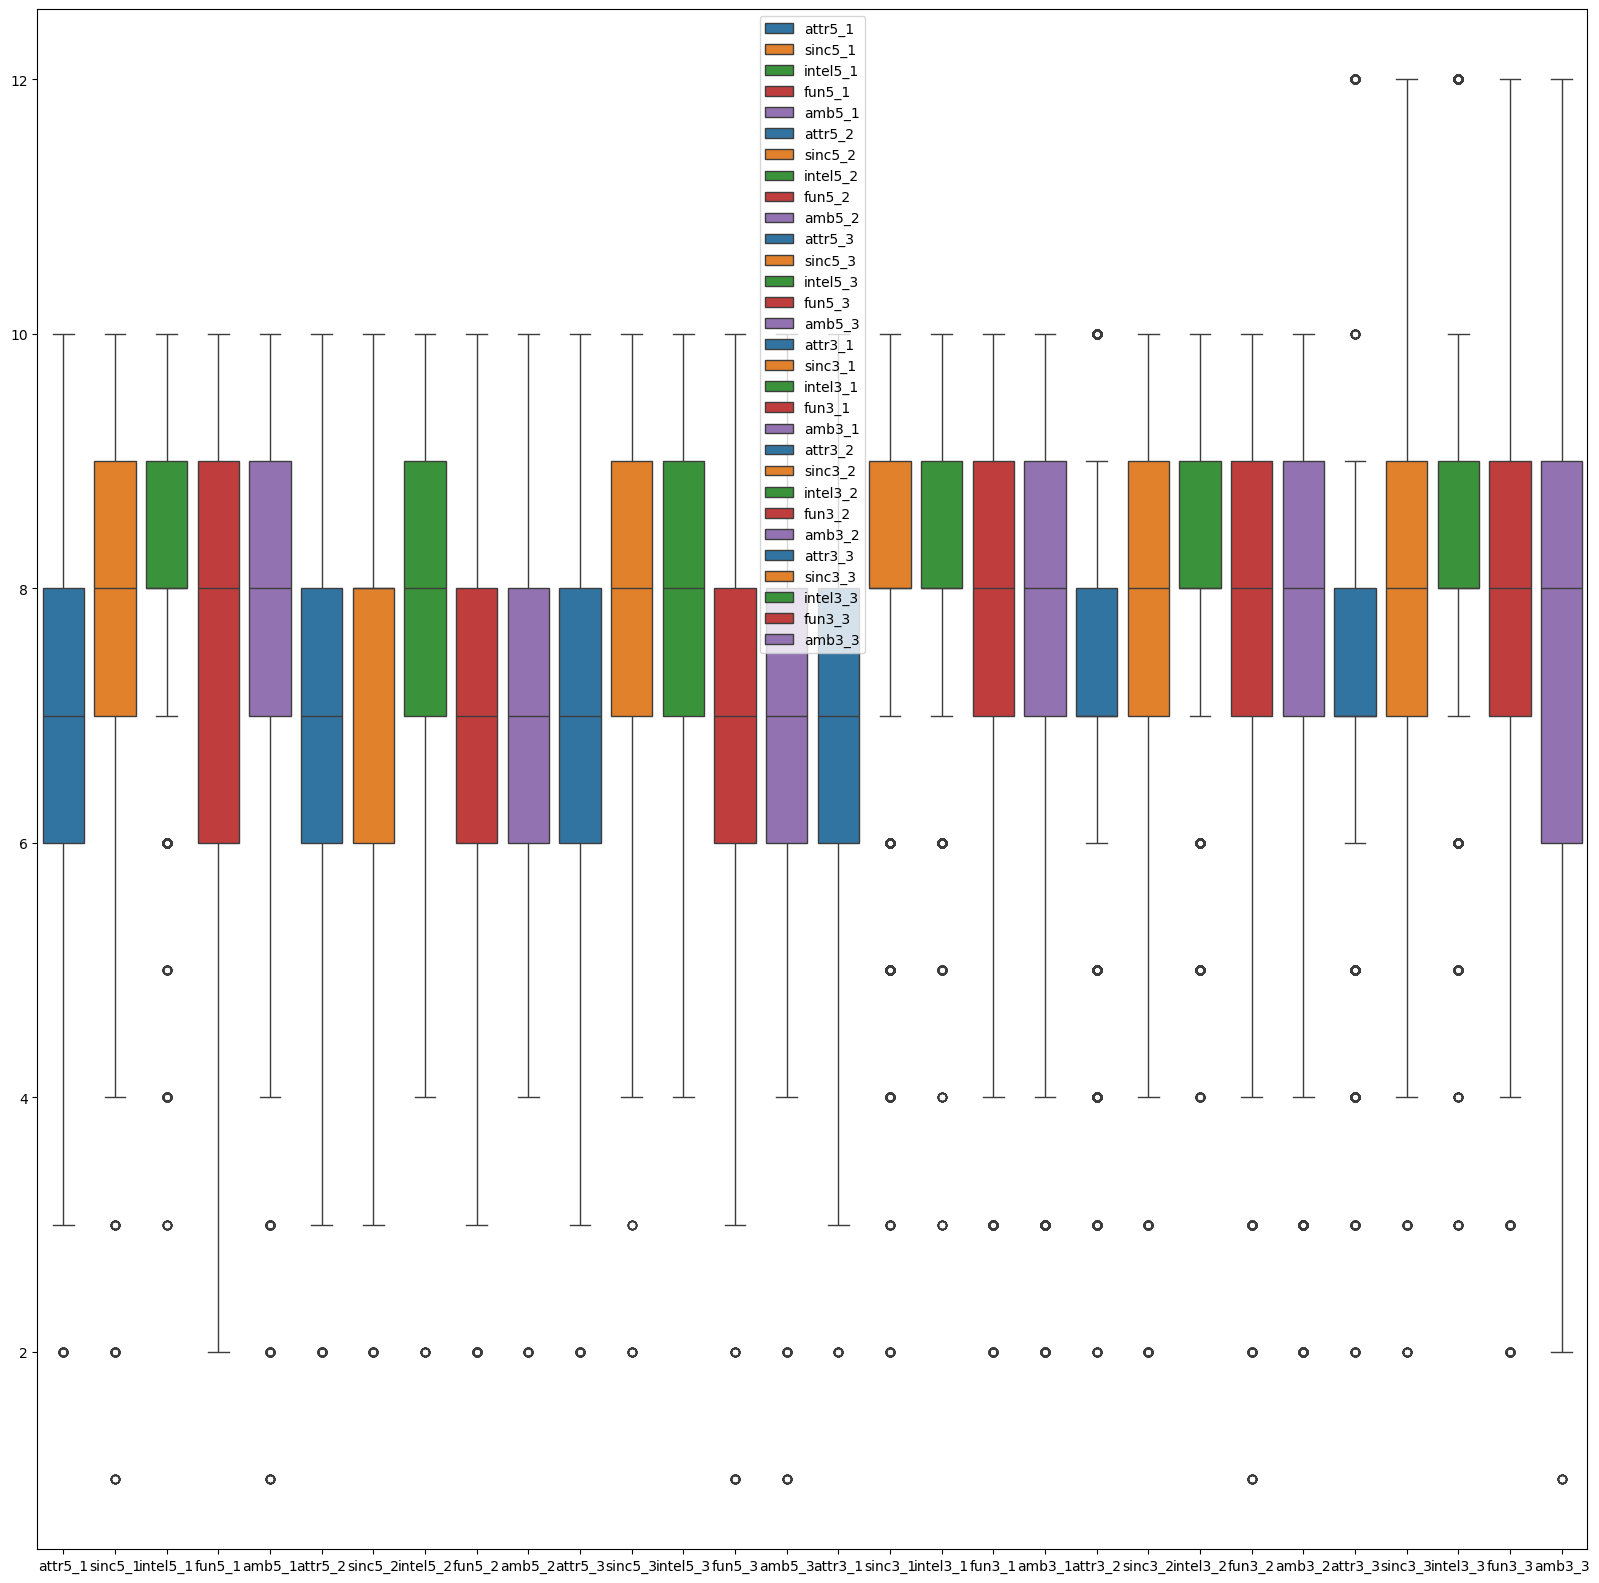

In [ ]:
# Boxplots of the ratings of the partner for each attribute of thie own perceived value, and the one they excpect others to have, for each attribute.
plt.subplots(figsize=(20, 20))
sns.boxplot(df[['attr5_1', 'sinc5_1', 'intel5_1', 'fun5_1', 'amb5_1']], legend= True)
sns.boxplot(df[['attr5_2', 'sinc5_2', 'intel5_2', 'fun5_2', 'amb5_2']], legend= True)
sns.boxplot(df[['attr5_3', 'sinc5_3', 'intel5_3', 'fun5_3', 'amb5_3']], legend= True)

sns.boxplot(df[['attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1']], legend= True)
sns.boxplot(df[['attr3_2', 'sinc3_2', 'intel3_2', 'fun3_2', 'amb3_2']], legend= True)
sns.boxplot(df[['attr3_3', 'sinc3_3', 'intel3_3', 'fun3_3', 'amb3_3']], legend= True)

<Axes: >

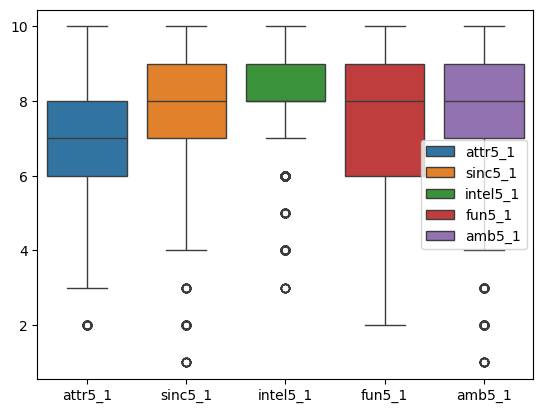

In [159]:
sns.boxplot(df[['attr5_1', 'sinc5_1', 'intel5_1', 'fun5_1', 'amb5_1']], legend= True)

## In terms of getting a second date, is it better to be someone's first speed date of the night or their last?

In [3]:
cols = ['attr_o','sinc_o','intel_o',
        'fun_o','amb_o','shar_o']

sub = df[cols + ['dec']].dropna()

X = sm.add_constant(sub[cols])
y = sub['dec']

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.671480
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                    dec   No. Observations:                 7031
Model:                          Logit   Df Residuals:                     7024
Method:                           MLE   Df Model:                            6
Date:                Mon, 16 Feb 2026   Pseudo R-squ.:                 0.01859
Time:                        12:11:34   Log-Likelihood:                -4721.2
converged:                       True   LL-Null:                       -4810.6
Covariance Type:            nonrobust   LLR p-value:                 5.807e-36
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9948      0.129     -7.729      0.000      -1.247      -0.743
attr_o        -0.1675      0.

## Does Choice Set Size Affect Selectivity?

In [8]:
df.groupby('condtn')['dec'].mean()

condtn
1    0.460251
2    0.411578
Name: dec, dtype: float64

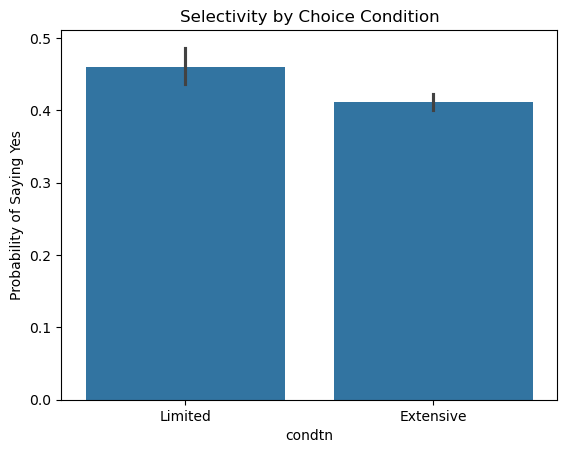

In [9]:

sns.barplot(data=df, x='condtn', y='dec')
plt.xticks([0,1], ['Limited', 'Extensive'])
plt.ylabel("Probability of Saying Yes")
plt.title("Selectivity by Choice Condition")
plt.show()

## Does Choice Condition Change What Traits Are Rewarded?

In [10]:
df[df['dec']==1].groupby('condtn')[
    ['attr_o','intel_o','fun_o','amb_o']
].mean()


,attr_o,intel_o,fun_o,amb_o
condtn,,,,
1,6.203364,7.514706,6.727132,7.035088
2,6.022100,7.516382,6.447764,6.879349


## Does Extensive Choice Increase Focus on Attractiveness?

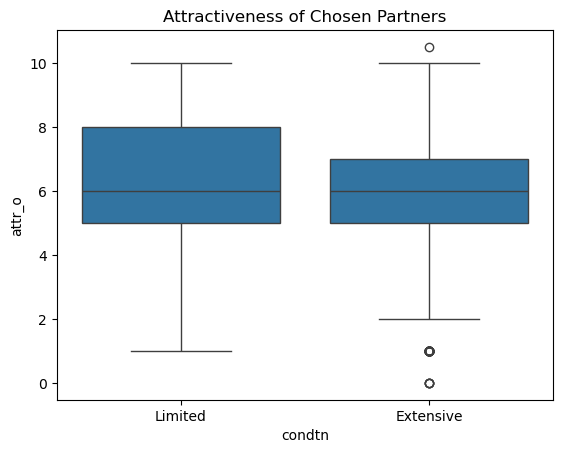

In [11]:
chosen = df[df['dec']==1]

sns.boxplot(data=chosen, x='condtn', y='attr_o')
plt.xticks([0,1], ['Limited','Extensive'])
plt.title("Attractiveness of Chosen Partners")
plt.show()


## Does Choice Condition Affect Match Probability?

In [12]:
df.groupby('condtn')['match'].mean()


condtn
1    0.202232
2    0.156970
Name: match, dtype: float64

<Axes: xlabel='condtn', ylabel='dec'>

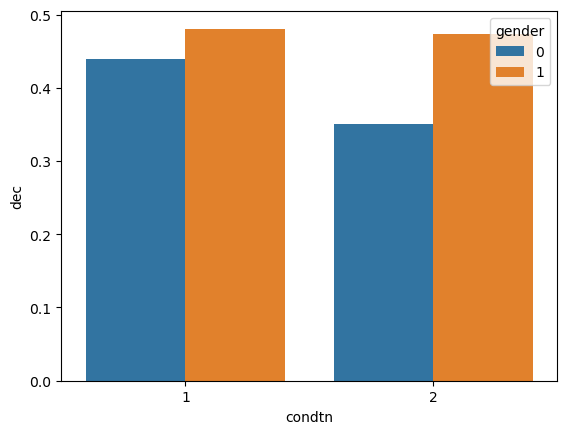

In [13]:
agg = df.groupby(['condtn','gender'])['dec'].mean().reset_index()

sns.barplot(data=agg, x='condtn', y='dec', hue='gender')

### Participants in the extensive choice condition show a lower probability of saying yes, suggesting increased selectivity. This aligns with choice overload theory, where larger choice sets lead to stricter evaluation thresholds.

## What Traits Actually Increase Second Dates?

In [14]:
cols = ['attr_o','sinc_o','intel_o','fun_o','amb_o','shar_o']

df.groupby('match')[cols].mean()


,attr_o,sinc_o,intel_o,fun_o,amb_o,shar_o
match,,,,,,
0,5.961320,7.045975,7.250522,6.154817,6.664778,5.208209
1,7.319898,7.809489,7.950365,7.598535,7.332949,6.753571


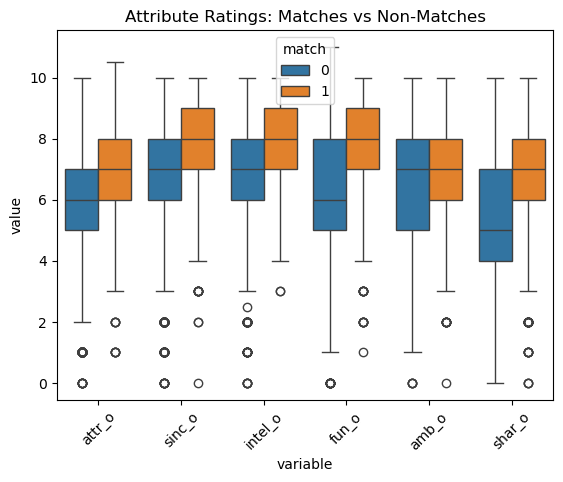

In [15]:

melted = df.melt(id_vars='match', value_vars=cols)

sns.boxplot(data=melted, x='variable', y='value', hue='match')
plt.xticks(rotation=45)
plt.title("Attribute Ratings: Matches vs Non-Matches")
plt.show()

## Do men and women reward different traits?

In [ ]:
df.groupby(['gender','match'])[cols].mean()

attr_o    sinc_o   intel_o     fun_o     amb_o    shar_o
gender match                                                            
0      0      6.246435  7.139427  7.182184  6.308996  6.484891  5.309516
       1      7.520319  7.798246  7.825292  7.552786  7.183409  6.654874
1      0      5.676289  6.952939  7.318860  5.999849  6.844665  5.104390
       1      7.119186  7.820700  8.075073  7.644217  7.485271  6.854167

<Axes: xlabel='gender', ylabel='attr_o'>

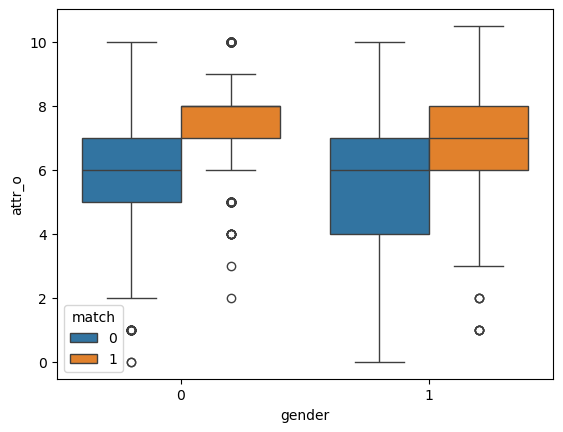

In [20]:
sns.boxplot(data=df, x='gender', y='attr_o', hue='match')